prompt:一首诗
content_type:poem
prompt:一首词
content_type:ci_poem
prompt:一个笑话
content_type:joke


{
    'poem': 
'《无题》\n云影沉山麓，松声入涧流。\n苔痕侵石径，鸟迹印林丘。\n露重花垂泪，风轻叶送秋。\n独行幽涧里，明月照孤舟。\n
\n注：此诗通过云影、松声、苔痕等意象，构建出幽深静谧的山林秋景。尾联“独行”“孤舟”的点染，让整幅画面流露出淡淡的孤寂
况味，而“明月照”三字又为这份孤寂镀上一层清冷的光辉，形成情景交融的意境。',
    'ci_poem': '《定风波·莫听穿林打叶声》  \n【宋】苏轼  \n\n莫听穿林打叶声，何妨吟啸且徐行。  
\n竹杖芒鞋轻胜马，谁怕？一蓑烟雨任平生。  \n料峭春风吹酒醒，微冷，山头斜照却相迎。  
\n回首向来萧瑟处，归去，也无风雨也无晴。  
\n\n此词为苏轼贬居黄州时所作，通过雨中从容漫步的描写，展现了作者面对人生逆境时超然旷达的胸怀。“一蓑烟雨任平生”与“也
无风雨也无晴”成为千古名句，道尽宠辱不惊、泰然自若的精神境界。',
    'joke': '有一个经典冷笑话：\n\n**小明去面试。**  \n面试官问：“你最大的缺点是什么？”  \n小明答：“我太诚实了。”  
\n面试官想了想：“我不觉得诚实是缺点啊。”  \n小明很高兴：“管你信不信，我才不在乎呢！”'
}

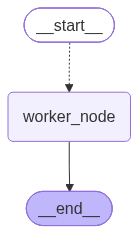

In [5]:
from typing import TypedDict, Literal
from collections.abc import Sequence

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain.messages import HumanMessage
from rich import print as rprint
from dotenv import load_dotenv
load_dotenv(override=True)

CONTENT_TYPES = ["poem", "ci_poem", "joke"]

model = ChatOpenAI(
    model = "deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    ci_poem: str
    joke: str

class WorkerState(TypedDict):
    """
    私有状态，只对 Worker 节点可用
    """
    content_type: Literal["poem", "ci_poem", "joke"]
    prompt: str

class InputState(TypedDict):
    topic: str

class OutputState(TypedDict):
    poem: str
    ci_poem: str
    joke: str

def worker_node(state: WorkerState) -> OutputState:
    content_type = state["content_type"]
    prompt = state["prompt"]

    content = model.invoke([HumanMessage(prompt)]).content
    return {
        content_type: content
    }

def router(state: InputState) -> Sequence[Send]:
    prompt = "请生成关于 {} 的 {}"
    english2chinese = {
        "poem": "一首诗",
        "ci_poem": "一首词",
        "joke": "一个笑话"
    }

    topic = state["topic"]

    return [Send(
            "worker_node",
            {
                "content_type": content_type,
                "prompt": prompt.format(topic, english2chinese[content_type]),
            }
        ) for content_type in CONTENT_TYPES
    ]

builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)
builder.add_node("worker_node", worker_node)
builder.add_conditional_edges(
    START,
    router,
    path_map=["worker_node"]
)
builder.add_edge("worker_node", END)

graph = builder.compile()
res = graph.invoke({"topic": "布偶狗"})
rprint(res)

from IPython.display import display
display(graph)